<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kesembilan/blob/main/Praktikum_9_2_MG_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


PRAKTIKUM 9.2: EDGE DETECTION DAN REGION-BASED SEGMENTATION

EDGE DETECTION RESULTS
----------------------------------------


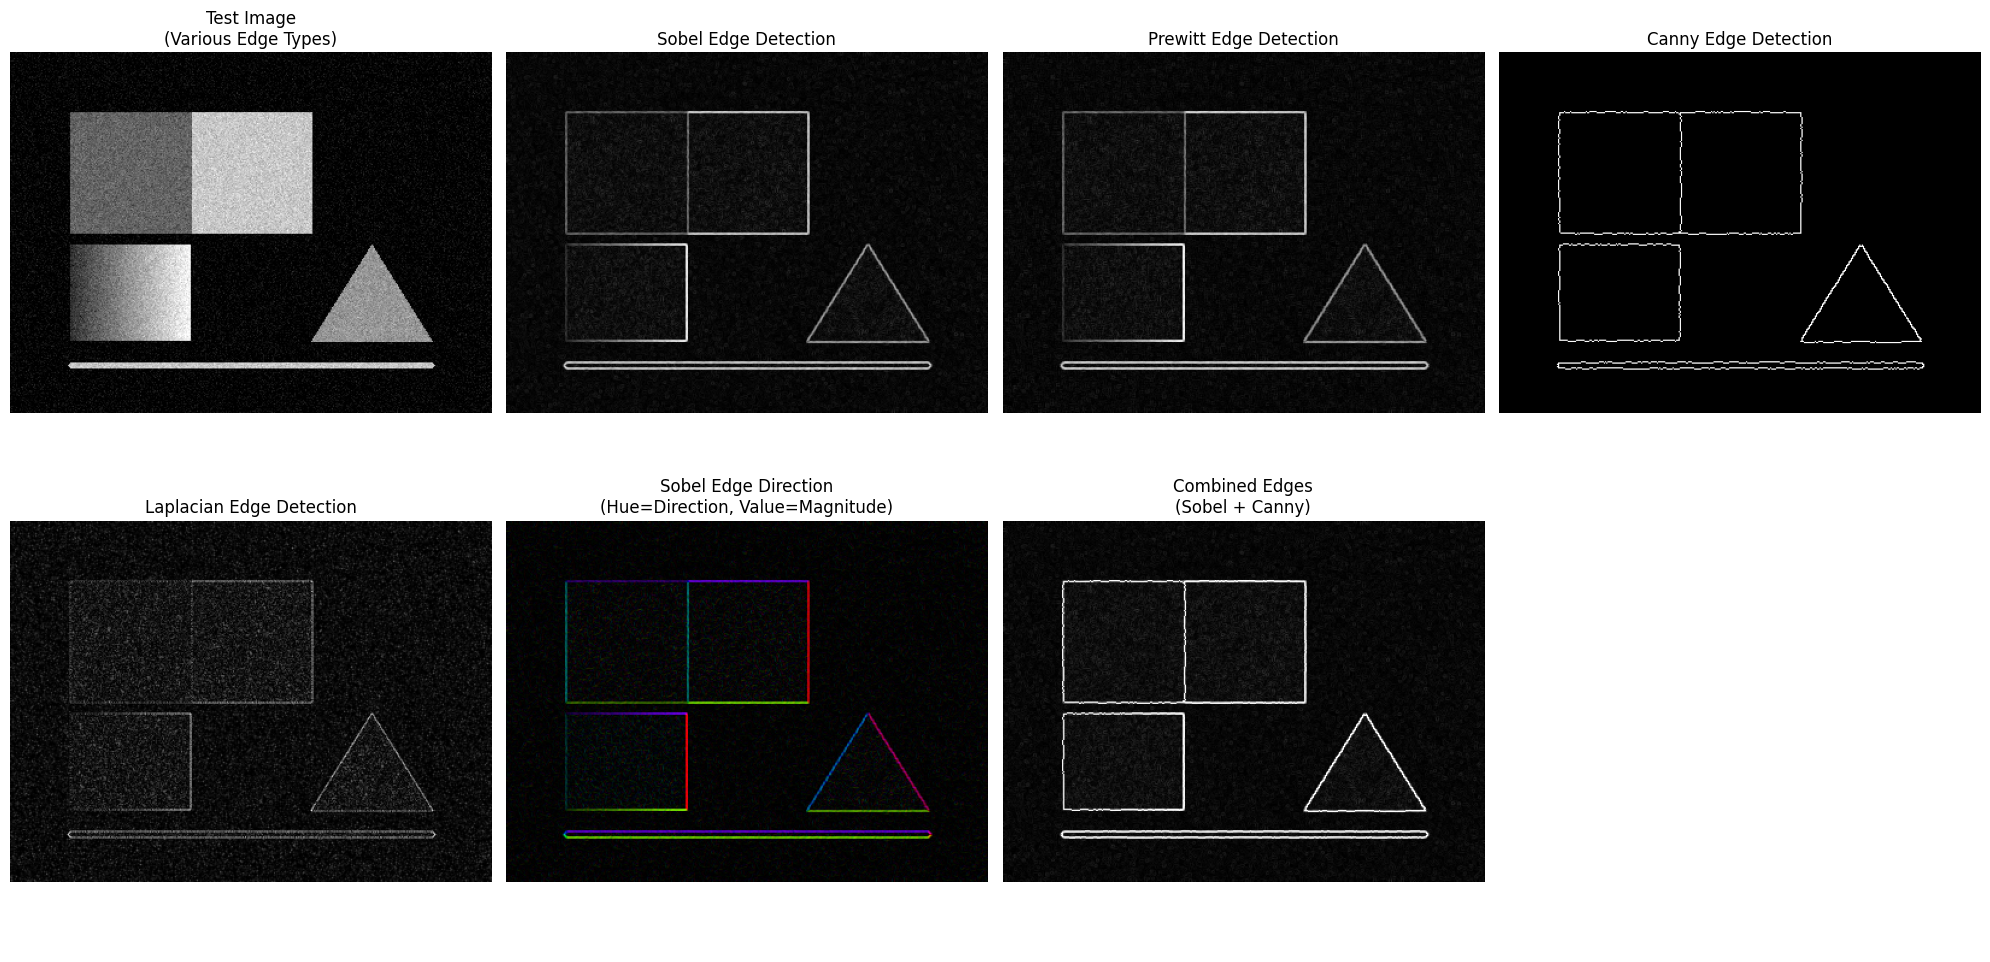


EDGE DETECTOR COMPARISON ANALYSIS
--------------------------------------------------
Method          Density    Components   Avg Size     Thinness  
------------------------------------------------------------
Sobel           0.0214     12           213.58       50.16     
Prewitt         0.0215     22           117.09       46.14     
Canny           0.0169     4            507.25       7.21      
Laplacian       0.0015     107          1.71         7.27      

REGION-BASED SEGMENTATION RESULTS
--------------------------------------------------


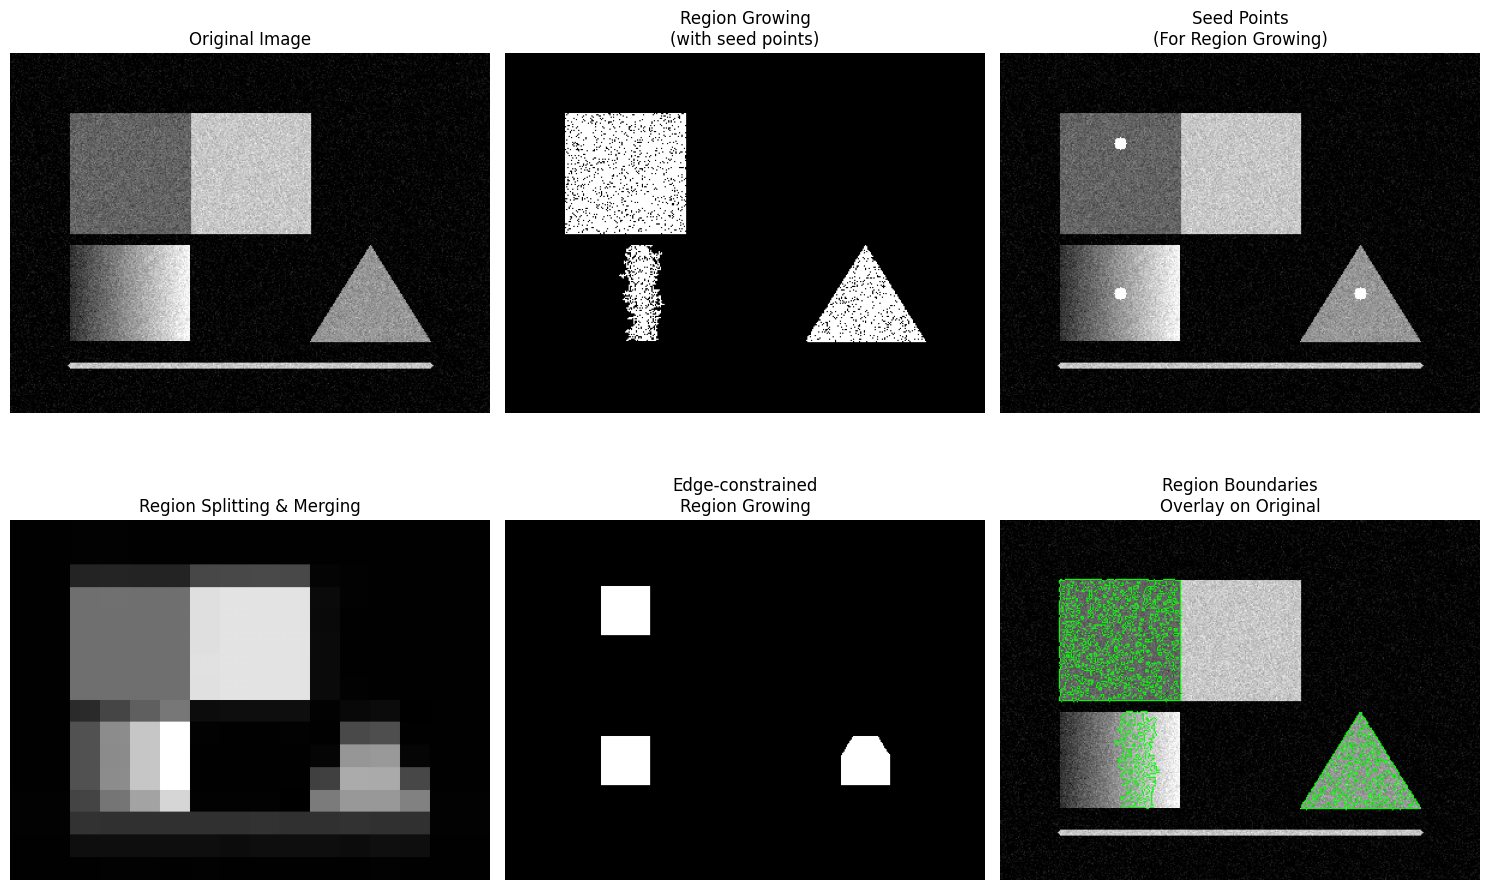


REGION CHARACTERISTICS ANALYSIS
--------------------------------------------------
Number of regions detected: 3

Region Statistics:
Region   Area       Mean       Std        Centroid            
------------------------------------------------------------
1        9238       99.47      11.97      (100.2, 100.1)
2        1596       177.62     13.88      (114.2, 198.9)
3        3716       150.28     11.87      (300.0, 213.5)


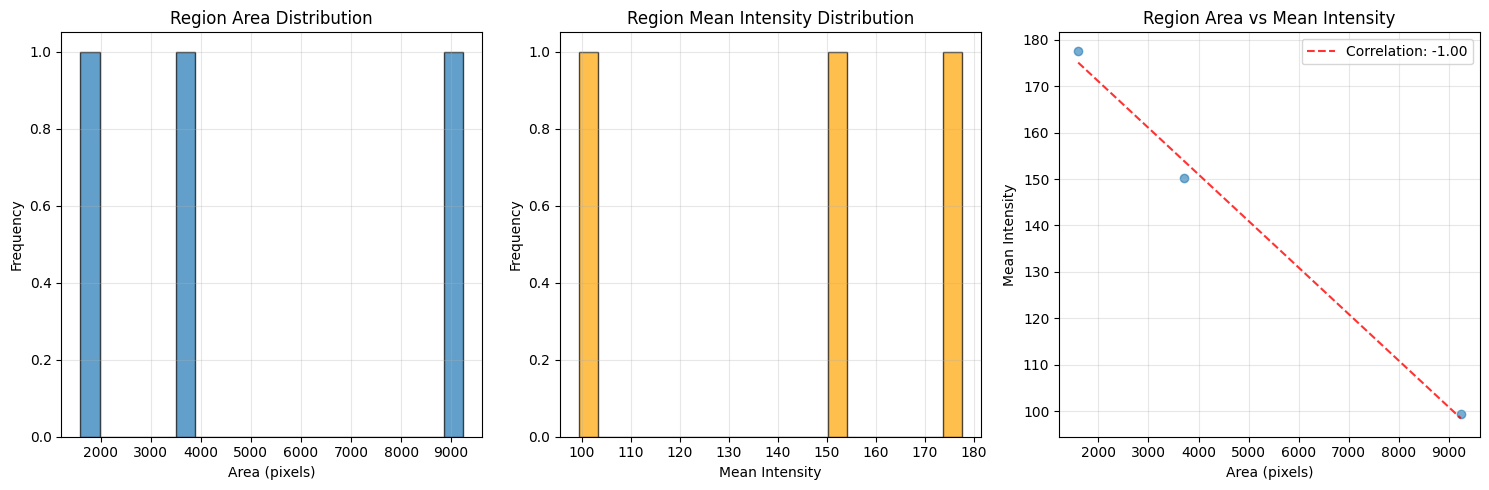


KESIMPULAN DAN APLIKASI PRAKTIS
----------------------------------------

1. Edge Detection:
   - Sobel/Prewitt : Baik untuk gradient magnitude, sensitif terhadap noise.
   - Canny         : Robust dengan noise reduction, menghasilkan thin edges.
   - Laplacian     : Deteksi zero-crossing, sensitif terhadap noise.

2. Region-based Methods:
   - Region Growing  : Intuitif, butuh seed points, sensitif terhadap parameter.
   - Split & Merge   : Fully automatic, cocok untuk regular structures.
   - Hybrid approach : Kombinasi edge dan region information.

3. Aplikasi Praktis:
   - Medical imaging  : Organ segmentation.
   - Remote sensing   : Land cover classification.
   - Industrial QC    : Defect detection.
   - Document analysis: Text region extraction.
    


In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def praktikum_9_2():
    """
    Implementasi edge detection dan region-based segmentation
    """
    print("\nPRAKTIKUM 9.2: EDGE DETECTION DAN REGION-BASED SEGMENTATION")
    print("=" * 70)

    # ------------------------------------------------------------------ #
    #  1. Buat citra test                                                  #
    # ------------------------------------------------------------------ #
    def create_edge_test_image():
        """Create test image with different edge types."""
        img = np.zeros((300, 400), dtype=np.uint8)

        # Step edge (sharp transition)
        cv2.rectangle(img, (50, 50),  (150, 150), 100, -1)
        cv2.rectangle(img, (151, 50), (250, 150), 200, -1)

        # Ramp edge (gradual transition)
        for i in range(50, 150):
            img[160:240, i] = 50 + (i - 50) * 2

        # Roof edge (triangular)
        # BUG FIX: dtype harus int32 agar drawContours berfungsi dengan benar
        triangle_cnt = np.array([(300, 160), (350, 240), (250, 240)],
                                 dtype=np.int32).reshape((-1, 1, 2))
        cv2.drawContours(img, [triangle_cnt], 0, 150, -1)

        # Line edge (thin line)
        cv2.line(img, (50, 260), (350, 260), 200, 3)

        # Add noise untuk testing robustness
        noise = np.random.normal(0, 15, img.shape)
        img = np.clip(img.astype(float) + noise, 0, 255).astype(np.uint8)

        return img

    # ------------------------------------------------------------------ #
    #  2. Edge detectors                                                   #
    # ------------------------------------------------------------------ #
    def apply_sobel_edge_detection(image, ksize=3):
        """Sobel edge detection — returns (magnitude uint8, direction float)."""
        sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=ksize)
        sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=ksize)

        magnitude = np.sqrt(sobelx**2 + sobely**2)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
        direction = np.arctan2(sobely, sobelx) * 180.0 / np.pi

        return magnitude.astype(np.uint8), direction

    def apply_prewitt_edge_detection(image):
        """Prewitt edge detection."""
        # BUG FIX: kernel arah x dan y ditukar di kode asli
        # kernelx seharusnya mendeteksi perubahan horizontal (grad vertikal)
        kernelx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float64)
        kernely = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float64)

        prewittx = cv2.filter2D(image.astype(np.float64), -1, kernelx)
        prewitty = cv2.filter2D(image.astype(np.float64), -1, kernely)

        magnitude = np.sqrt(prewittx**2 + prewitty**2)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

        return magnitude.astype(np.uint8)

    def apply_canny_edge_detection(image, low_threshold=50, high_threshold=150):
        """Canny edge detection with Gaussian pre-blur."""
        blurred = cv2.GaussianBlur(image, (5, 5), 1.4)
        edges   = cv2.Canny(blurred, low_threshold, high_threshold)
        return edges

    def apply_laplacian_edge_detection(image):
        """Laplacian edge detection."""
        laplacian = cv2.Laplacian(image, cv2.CV_64F)
        laplacian = np.abs(laplacian)
        laplacian = cv2.normalize(laplacian, None, 0, 255, cv2.NORM_MINMAX)
        return laplacian.astype(np.uint8)

    # ------------------------------------------------------------------ #
    #  3. Region-based segmentation                                        #
    # ------------------------------------------------------------------ #
    def region_growing_segmentation(image, seeds, threshold=20):
        """
        Region growing segmentation.
        BUG FIX: koordinat seed (row, col) dipakai konsisten.
        """
        segmented = np.zeros_like(image)
        visited   = np.zeros(image.shape, dtype=bool)

        if isinstance(seeds, tuple) and not isinstance(seeds[0], tuple):
            seeds = [seeds]   # single seed

        for seed in seeds:
            r, c = seed
            if not (0 <= r < image.shape[0] and 0 <= c < image.shape[1]):
                continue
            if visited[r, c]:
                continue

            stack          = [(r, c)]
            region_pixels  = []

            while stack:
                x, y = stack.pop()

                if visited[x, y]:
                    continue

                visited[x, y] = True
                region_pixels.append(float(image[x, y]))
                segmented[x, y] = 255

                region_mean = np.mean(region_pixels)

                for nx, ny in [(x-1, y), (x+1, y), (x, y-1), (x, y+1)]:
                    if (0 <= nx < image.shape[0] and 0 <= ny < image.shape[1]
                            and not visited[nx, ny]):
                        if abs(float(image[nx, ny]) - region_mean) < threshold:
                            stack.append((nx, ny))

        return segmented

    def region_splitting_merging(image, min_size=32, threshold=20):
        """
        Region splitting and merging — menghasilkan label map.
        BUG FIX: hasil visualisasi sebelumnya hanya mengisi pojok kiri-atas;
        sekarang setiap region diisi ke posisi aslinya menggunakan quadtree rekursif.
        """
        h, w      = image.shape
        label_map = np.zeros((h, w), dtype=np.int32)
        label_id  = [1]   # mutable counter

        def process(r0, c0, rh, rw):
            """Rekursif split; beri label saat tidak perlu split lagi."""
            if rh < 1 or rw < 1:
                return
            region = image[r0:r0+rh, c0:c0+rw]
            if np.std(region) > threshold and rh > min_size and rw > min_size:
                # Split menjadi 4 kuadran
                hh, hw = rh // 2, rw // 2
                process(r0,      c0,      hh,      hw)
                process(r0,      c0 + hw, hh,      rw - hw)
                process(r0 + hh, c0,      rh - hh, hw)
                process(r0 + hh, c0 + hw, rh - hh, rw - hw)
            else:
                label_map[r0:r0+rh, c0:c0+rw] = label_id[0]
                label_id[0] += 1

        process(0, 0, h, w)

        # Merge: ratakan nilai label menjadi intensitas untuk visualisasi
        n_labels  = label_id[0]
        vis_image = np.zeros((h, w), dtype=np.uint8)
        for lbl in range(1, n_labels):
            mask  = (label_map == lbl)
            if mask.any():
                mean_val = np.mean(image[mask])
                vis_image[mask] = np.clip(int(mean_val), 0, 255)

        return vis_image

    # ------------------------------------------------------------------ #
    #  4. Jalankan semua metode                                            #
    # ------------------------------------------------------------------ #
    test_image = create_edge_test_image()

    # Edge detection
    sobel_magnitude, sobel_direction = apply_sobel_edge_detection(test_image)
    prewitt_magnitude                = apply_prewitt_edge_detection(test_image)
    canny_edges                      = apply_canny_edge_detection(test_image)
    laplacian_edges                  = apply_laplacian_edge_detection(test_image)

    edge_results = {
        'Sobel':     sobel_magnitude,
        'Prewitt':   prewitt_magnitude,
        'Canny':     canny_edges,
        'Laplacian': laplacian_edges,
    }

    # Region-based segmentation
    # seeds dalam format (row, col)
    seeds = [(75, 100), (200, 100), (200, 300)]

    region_grown      = region_growing_segmentation(test_image, seeds, threshold=25)
    split_merge_result = region_splitting_merging(test_image, min_size=32, threshold=20)

    region_results = {
        'Region Growing': region_grown,
        'Split & Merge':  split_merge_result,
    }

    # ------------------------------------------------------------------ #
    #  5. Visualisasi edge detection                                       #
    # ------------------------------------------------------------------ #
    print("\nEDGE DETECTION RESULTS")
    print("-" * 40)

    # BUG FIX: pakai (2, 4) agar row-0 cukup untuk Original + Sobel + Prewitt + Canny
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    # Row 0: Original + 3 edge detectors
    axes[0, 0].imshow(test_image, cmap='gray')
    axes[0, 0].set_title('Test Image\n(Various Edge Types)')
    axes[0, 0].axis('off')

    for idx, method in enumerate(['Sobel', 'Prewitt', 'Canny'], start=1):
        axes[0, idx].imshow(edge_results[method], cmap='gray')
        axes[0, idx].set_title(f'{method} Edge Detection')
        axes[0, idx].axis('off')

    # Row 1: Laplacian + Sobel direction + Combined + (kosong)
    axes[1, 0].imshow(edge_results['Laplacian'], cmap='gray')
    axes[1, 0].set_title('Laplacian Edge Detection')
    axes[1, 0].axis('off')

    # Sobel direction sebagai HSV — normalisasi Hue ke [0, 179]
    hsv         = np.zeros((*test_image.shape, 3), dtype=np.uint8)
    hsv[..., 0] = np.clip((sobel_direction + 180.0) / 360.0 * 179.0, 0, 179).astype(np.uint8)
    hsv[..., 1] = 255
    hsv[..., 2] = sobel_magnitude
    axes[1, 1].imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
    axes[1, 1].set_title('Sobel Edge Direction\n(Hue=Direction, Value=Magnitude)')
    axes[1, 1].axis('off')

    # Combined edges (Sobel + Canny)
    combined_edges = np.maximum(
        sobel_magnitude.astype(np.float32),
        canny_edges.astype(np.float32)
    ).astype(np.uint8)
    axes[1, 2].imshow(combined_edges, cmap='gray')
    axes[1, 2].set_title('Combined Edges\n(Sobel + Canny)')
    axes[1, 2].axis('off')

    axes[1, 3].axis('off')   # kolom terakhir dikosongkan

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    #  6. Analisis komparatif edge detectors                               #
    # ------------------------------------------------------------------ #
    print("\nEDGE DETECTOR COMPARISON ANALYSIS")
    print("-" * 50)

    def analyze_edge_image(edge_image, threshold=128):
        """Analyze edge image characteristics."""
        binary_edges = (edge_image > threshold).astype(np.uint8)

        edge_density = np.sum(binary_edges) / binary_edges.size

        num_labels, _ = cv2.connectedComponents(binary_edges)
        n_components   = max(num_labels - 1, 1)
        avg_component_size = np.sum(binary_edges) / n_components

        contours, _ = cv2.findContours(binary_edges,
                                       cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        thinness_ratios = []
        for contour in contours:
            area      = cv2.contourArea(contour)
            perimeter = cv2.arcLength(contour, True)
            if area > 0 and perimeter > 0:
                thinness_ratios.append(perimeter**2 / (4 * np.pi * area))

        avg_thinness = np.mean(thinness_ratios) if thinness_ratios else 0.0

        return {
            'density':            edge_density,
            'num_components':     n_components,
            'avg_component_size': avg_component_size,
            'avg_thinness':       avg_thinness,
        }

    print(f"{'Method':<15} {'Density':<10} {'Components':<12} "
          f"{'Avg Size':<12} {'Thinness':<10}")
    print("-" * 60)

    for method_name, edge_image in edge_results.items():
        a = analyze_edge_image(edge_image)
        print(f"{method_name:<15} {a['density']:<10.4f} {a['num_components']:<12} "
              f"{a['avg_component_size']:<12.2f} {a['avg_thinness']:<10.2f}")

    # ------------------------------------------------------------------ #
    #  7. Visualisasi region-based segmentation                            #
    # ------------------------------------------------------------------ #
    print("\nREGION-BASED SEGMENTATION RESULTS")
    print("-" * 50)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    axes[0, 0].imshow(test_image, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(region_results['Region Growing'], cmap='gray')
    axes[0, 1].set_title('Region Growing\n(with seed points)')
    axes[0, 1].axis('off')

    # Tampilkan seed points — seed = (row, col), cv2.circle minta (col, row)
    seed_display = test_image.copy()
    for seed in seeds:
        cv2.circle(seed_display, (seed[1], seed[0]), 5, 255, -1)
    axes[0, 2].imshow(seed_display, cmap='gray')
    axes[0, 2].set_title('Seed Points\n(For Region Growing)')
    axes[0, 2].axis('off')

    axes[1, 0].imshow(region_results['Split & Merge'], cmap='gray')
    axes[1, 0].set_title('Region Splitting & Merging')
    axes[1, 0].axis('off')

    # Edge-constrained region growing
    edge_constrained = cv2.dilate(canny_edges,
                                  np.ones((3, 3), np.uint8),
                                  iterations=1)

    constrained_result = np.zeros_like(test_image)
    for seed in seeds:
        mask = np.zeros_like(test_image, dtype=np.uint8)
        mask[seed[0], seed[1]] = 1
        for _ in range(20):
            dilated = cv2.dilate(mask, np.ones((3, 3), np.uint8))
            dilated[edge_constrained > 0] = 0
            if np.array_equal(dilated, mask):
                break
            mask = dilated
        constrained_result[mask > 0] = 255

    axes[1, 1].imshow(constrained_result, cmap='gray')
    axes[1, 1].set_title('Edge-constrained\nRegion Growing')
    axes[1, 1].axis('off')

    # Region boundaries overlay
    boundaries = cv2.Canny(region_results['Region Growing'].astype(np.uint8), 50, 150)
    overlay    = cv2.cvtColor(test_image, cv2.COLOR_GRAY2BGR)
    overlay[boundaries > 0] = [0, 255, 0]
    axes[1, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('Region Boundaries\nOverlay on Original')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    #  8. Analisis region characteristics                                  #
    # ------------------------------------------------------------------ #
    print("\nREGION CHARACTERISTICS ANALYSIS")
    print("-" * 50)

    def analyze_regions(binary_image, source_image):
        """Analyze segmented regions using connectedComponentsWithStats."""
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            binary_image, connectivity=8
        )

        region_info = []
        for i in range(1, num_labels):   # skip background
            area   = stats[i, cv2.CC_STAT_AREA]
            left   = stats[i, cv2.CC_STAT_LEFT]
            top    = stats[i, cv2.CC_STAT_TOP]
            width  = stats[i, cv2.CC_STAT_WIDTH]
            height = stats[i, cv2.CC_STAT_HEIGHT]

            region_pixels = source_image[labels == i]

            region_info.append({
                'label':          i,
                'area':           area,
                'centroid':       centroids[i],
                'mean_intensity': float(np.mean(region_pixels)),
                'std_intensity':  float(np.std(region_pixels)),
                'bbox':           (left, top, width, height),
            })

        return region_info

    region_grown_binary = (region_results['Region Growing'] > 0).astype(np.uint8)
    # BUG FIX: teruskan source_image agar intensitas diambil dari citra asli
    region_info = analyze_regions(region_grown_binary, test_image)

    print(f"Number of regions detected: {len(region_info)}")
    print("\nRegion Statistics:")
    print(f"{'Region':<8} {'Area':<10} {'Mean':<10} {'Std':<10} {'Centroid':<20}")
    print("-" * 60)

    for info in region_info[:5]:
        cx, cy = info['centroid']
        print(f"{info['label']:<8} {info['area']:<10} {info['mean_intensity']:<10.2f} "
              f"{info['std_intensity']:<10.2f} ({cx:.1f}, {cy:.1f})")

    # ------------------------------------------------------------------ #
    #  9. Visualisasi distribusi region properties                         #
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    areas       = [info['area']           for info in region_info]
    intensities = [info['mean_intensity'] for info in region_info]

    axes[0].hist(areas, bins=20, alpha=0.7, edgecolor='black')
    axes[0].set_title('Region Area Distribution')
    axes[0].set_xlabel('Area (pixels)')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(intensities, bins=20, alpha=0.7, edgecolor='black', color='orange')
    axes[1].set_title('Region Mean Intensity Distribution')
    axes[1].set_xlabel('Mean Intensity')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)

    axes[2].scatter(areas, intensities, alpha=0.6)
    axes[2].set_title('Region Area vs Mean Intensity')
    axes[2].set_xlabel('Area (pixels)')
    axes[2].set_ylabel('Mean Intensity')
    axes[2].grid(True, alpha=0.3)

    # BUG FIX: cek minimal 2 titik unik sebelum polyfit agar tidak error
    if len(areas) > 1 and len(set(areas)) > 1:
        z   = np.polyfit(areas, intensities, 1)
        p   = np.poly1d(z)
        xs  = sorted(areas)
        corr = np.corrcoef(areas, intensities)[0, 1]
        axes[2].plot(xs, p(xs), "r--", alpha=0.8,
                     label=f'Correlation: {corr:.2f}')
        axes[2].legend()

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    #  10. Kesimpulan                                                      #
    # ------------------------------------------------------------------ #
    print("\nKESIMPULAN DAN APLIKASI PRAKTIS")
    print("-" * 40)
    print("""
1. Edge Detection:
   - Sobel/Prewitt : Baik untuk gradient magnitude, sensitif terhadap noise.
   - Canny         : Robust dengan noise reduction, menghasilkan thin edges.
   - Laplacian     : Deteksi zero-crossing, sensitif terhadap noise.

2. Region-based Methods:
   - Region Growing  : Intuitif, butuh seed points, sensitif terhadap parameter.
   - Split & Merge   : Fully automatic, cocok untuk regular structures.
   - Hybrid approach : Kombinasi edge dan region information.

3. Aplikasi Praktis:
   - Medical imaging  : Organ segmentation.
   - Remote sensing   : Land cover classification.
   - Industrial QC    : Defect detection.
   - Document analysis: Text region extraction.
    """)

    return test_image, edge_results, region_results


# ------------------------------------------------------------------ #
#  Entry point                                                         #
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    edge_test_image, edge_results, region_results = praktikum_9_2()
